In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "[your username here]"
os.environ['KAGGLE_KEY'] = "[your key here]"

print("Kaggle credentials set")

Kaggle credentials set


In [ ]:
!pip install kaggle -q

!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset -q

!unzip -q the-fake-or-real-dataset.zip -d fake_or_real

print("Dataset ready")

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
Dataset ready


In [ ]:
import os
def show_structure(path, depth=3, indent=0):
    if depth == 0:
        return
    for item in os.listdir(path):
        print("  " * indent + item)
        full = os.path.join(path, item)
        if os.path.isdir(full):
            show_structure(full, depth - 1, indent + 1)

show_structure("fake_or_real")

for-rerec
  for-rerecorded
    validation
    training
    testing
for-norm
  for-norm
    validation
    training
    testing
for-original
  for-original
    validation
    training
    testing
for-2sec
  for-2seconds
    validation
    training
    testing


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("All libraries imported successfully")
print(f"Librosa version: {librosa.__version__}")

All libraries imported successfully
Librosa version: 0.11.0


## Exploratory Data Analysis (EDA)

Before finalizing our preprocessing parameters, we analyze the dataset to understand:
- Class distribution (are the classes balanced?)
- Audio duration distribution (how long are the files? this decides our fixed duration)
- Sample rate distribution (what rates exist? this confirms our target SR)
- MFCC shape distribution (how many time frames do we naturally get?)

These insights directly inform our preprocessing decisions.

In [ ]:
BASE_DIR = "fake_or_real/for-norm/for-norm"

TRAIN_DIR = os.path.join(BASE_DIR, "training")
VAL_DIR   = os.path.join(BASE_DIR, "validation")
TEST_DIR  = os.path.join(BASE_DIR, "testing")

CLASSES = ["real", "fake"]

for split, path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    for cls in CLASSES:
        count = len(os.listdir(os.path.join(path, cls)))
        print(f"{split} → {cls}: {count} files")
    print()

Train → real: 26941 files
Train → fake: 26927 files

Val → real: 5400 files
Val → fake: 5398 files

Test → real: 2264 files
Test → fake: 2370 files



Class distribution analysis shows that the Real and Fake classes are nearly equally represented across all dataset splits. Therefore, the dataset can be used directly for model training without applying any class imbalance correction techniques.

In [ ]:
import os

# Check exactly what splits exist in for-norm
norm_path = "fake_or_real/for-norm/for-norm"
print("for-norm splits:", os.listdir(norm_path))

for-norm splits: ['validation', 'training', 'testing']


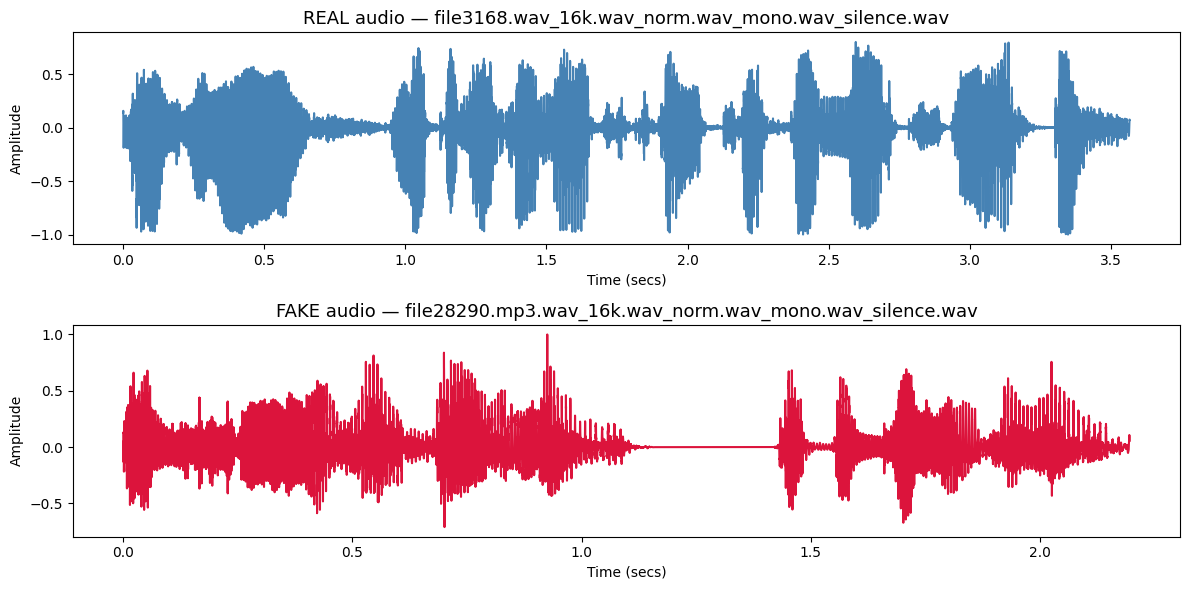

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

for idx, cls in enumerate(CLASSES):
    folder = os.path.join(TRAIN_DIR, cls)
    sample_file = os.listdir(folder)[0]
    file_path = os.path.join(folder, sample_file)

    audio, sr = librosa.load(file_path, sr=None)

    axes[idx].plot(np.linspace(0, len(audio)/sr, len(audio)), audio, color='steelblue' if cls == 'real' else 'crimson')
    axes[idx].set_title(f"{cls.upper()} audio — {sample_file}", fontsize=13)
    axes[idx].set_xlabel("Time (secs)")
    axes[idx].set_ylabel("Amplitude")

plt.tight_layout()\

plt.show()

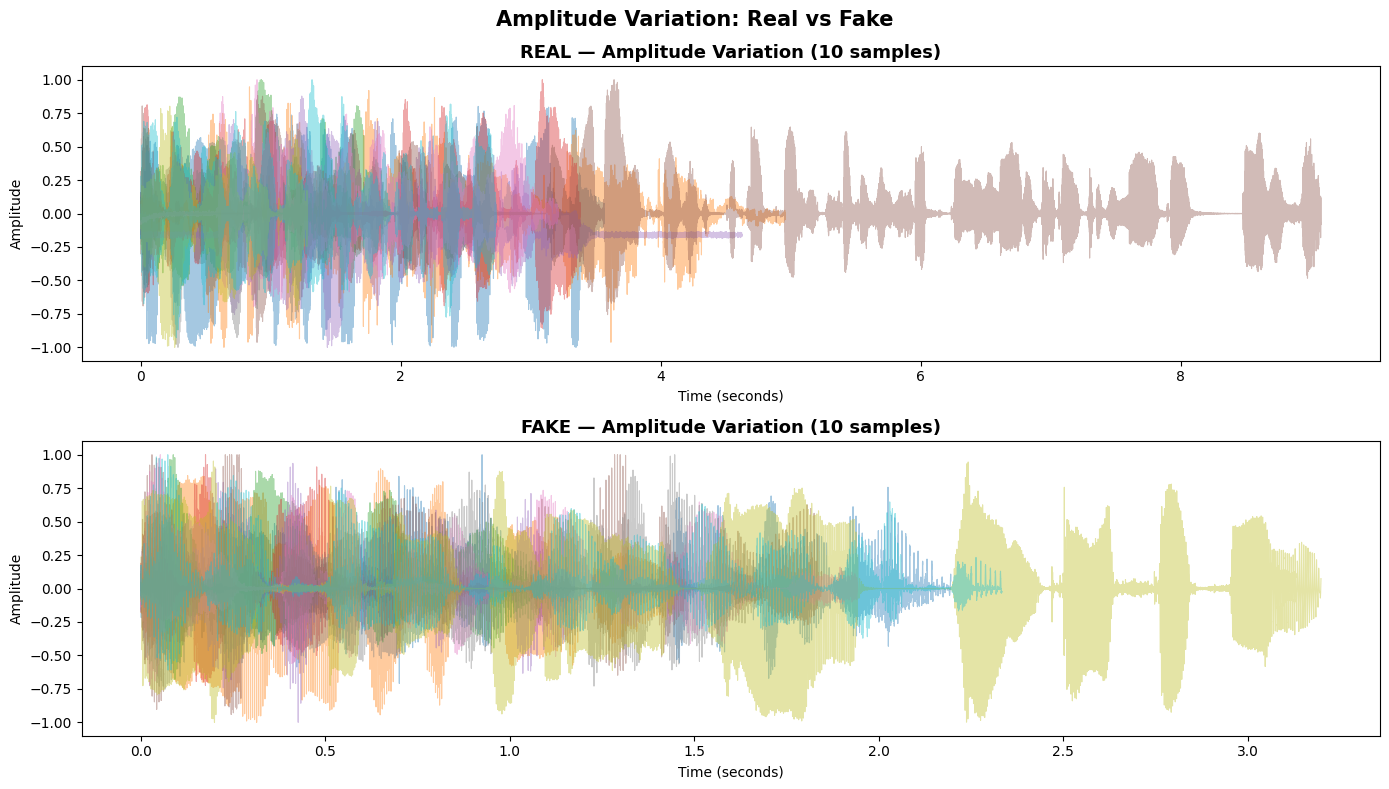

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

N_SAMPLES = 10

for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(cls_dir)[:N_SAMPLES]

    for fname in files:
        audio, sr = librosa.load(os.path.join(cls_dir, fname), sr=None)
        time = np.linspace(0, len(audio)/sr, len(audio))
        axes[i].plot(time, audio, alpha=0.4, linewidth=0.8)

    axes[i].set_title(f"{cls.upper()} — Amplitude Variation ({N_SAMPLES} samples)",
                      fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Time (seconds)")
    axes[i].set_ylabel("Amplitude")

plt.suptitle("Amplitude Variation: Real vs Fake", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

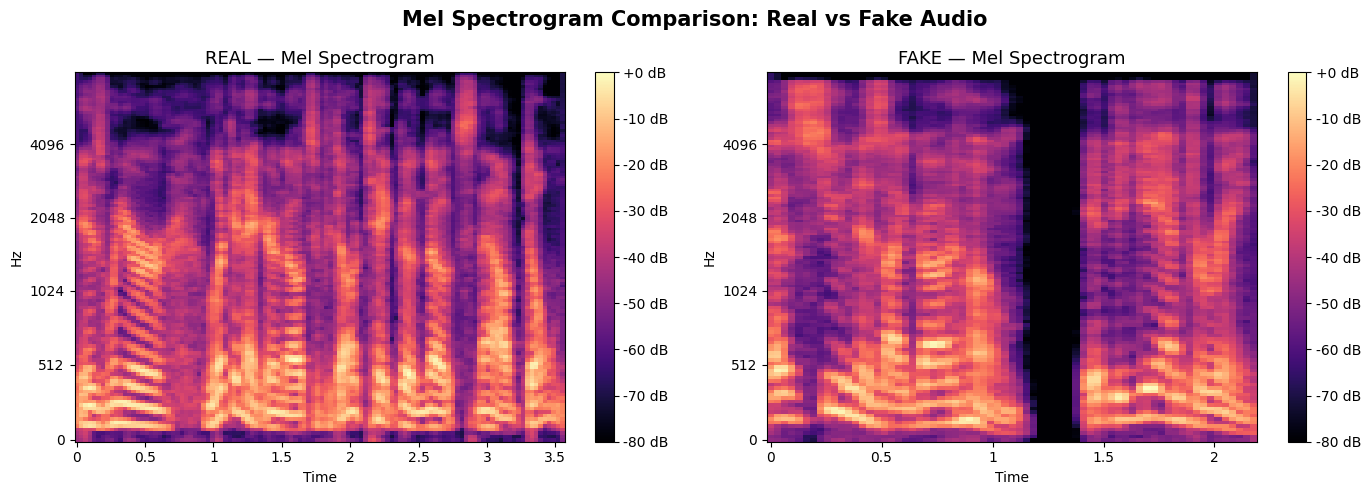

In [ ]:
# Mel spectrograms give us a rich visual representation of audio
# Real and fake audio often differ in texture, smoothness, and frequency distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, cls in enumerate(CLASSES):
    folder = os.path.join(TRAIN_DIR, cls)
    sample_file = os.listdir(folder)[0]
    file_path = os.path.join(folder, sample_file)

    audio, sr = librosa.load(file_path, sr=16000)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[idx])
    axes[idx].set_title(f"{cls.upper()} — Mel Spectrogram", fontsize=13)
    fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')

plt.suptitle("Mel Spectrogram Comparison: Real vs Fake Audio", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Mel spectrograms were generated to visually inspect the acoustic characteristics of genuine and deepfake speech samples. Although differences are not always obvious to the human eye, these representations reveal time-frequency structures from which deepfake artifacts may be learned by machine learning models."

In [ ]:
import librosa
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# We'll sample a subset for speed — analyzing all 53k files would take too long
SAMPLE_SIZE = 5000  # per class per split

eda_records = []

for split, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR), ("val", VAL_DIR)]:
    for cls in CLASSES:
        cls_dir = os.path.join(split_dir, cls)
        files = os.listdir(cls_dir)

        # randomly sample to keep EDA fast
        sampled = np.random.choice(files, min(SAMPLE_SIZE, len(files)), replace=False)

        for fname in tqdm(sampled, desc=f"{split}/{cls}"):
            fpath = os.path.join(cls_dir, fname)
            try:
                audio, sr = librosa.load(fpath, sr=None)
                duration = len(audio) / sr
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                mfcc_frames = mfcc.shape[1]

                eda_records.append({
                    "split"      : split,
                    "class"      : cls,
                    "sample_rate": sr,
                    "duration"   : duration,
                    "mfcc_frames": mfcc_frames
                })
            except:
                continue

import pandas as pd
eda_df = pd.DataFrame(eda_records)
print(f"/n EDA collected on {len(eda_df)} samples")
print(eda_df.head())

val/fake: 100%|██████████| 5000/5000 [00:37<00:00, 133.94it/s]


/n EDA collected on 24634 samples
   split class  sample_rate  duration  mfcc_frames
0  train  real        16000  4.874313          153
1  train  real        16000  8.695312          272
2  train  real        16000  2.022500           64
3  train  real        16000  4.987563          156
4  train  real        16000  3.124375           98


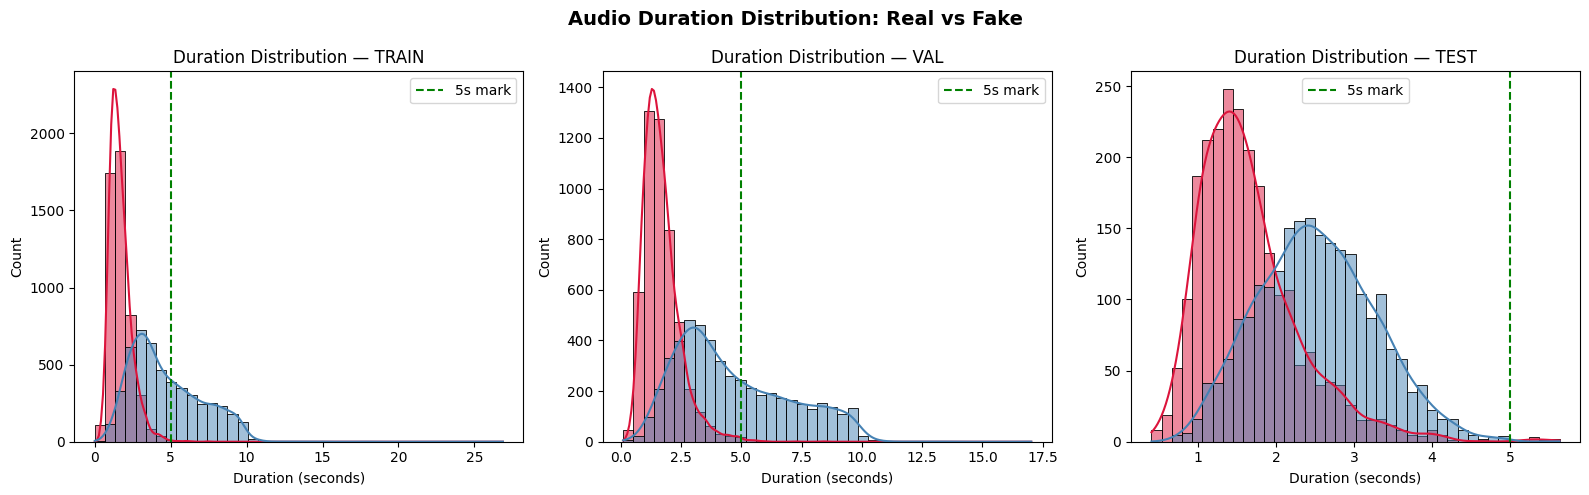


Duration Statistics:
         count  mean   std   min   25%   50%   75%    max
class                                                    
fake   12370.0  1.68  0.72  0.23  1.18  1.54  2.01   8.41
real   12264.0  4.27  2.28  0.00  2.54  3.55  5.67  26.88


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for idx, split in enumerate(["train", "val", "test"]):
    subset = eda_df[eda_df["split"] == split]

    sns.histplot(data=subset, x="duration", hue="class",
                 palette={"real": "steelblue", "fake": "crimson"},
                 bins=40, kde=True, ax=axes[idx])

    axes[idx].set_title(f"Duration Distribution — {split.upper()}", fontsize=12)
    axes[idx].set_xlabel("Duration (seconds)")
    axes[idx].set_ylabel("Count")
    axes[idx].axvline(x=5, color='green', linestyle='--', label='5s mark')
    axes[idx].legend()

plt.suptitle("Audio Duration Distribution: Real vs Fake", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print key stats
print("\nDuration Statistics:")
print(eda_df.groupby("class")["duration"].describe().round(2))

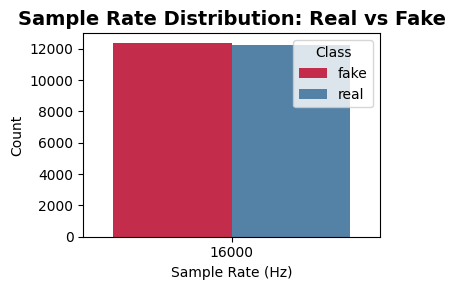


Unique sample rates found:
sample_rate
16000    24634
Name: count, dtype: int64


In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

sr_counts = eda_df.groupby(["class", "sample_rate"]).size().reset_index(name="count")

sns.barplot(data=sr_counts, x="sample_rate", y="count", hue="class",
            palette={"real": "steelblue", "fake": "crimson"}, ax=ax)

ax.set_title("Sample Rate Distribution: Real vs Fake", fontsize=14, fontweight="bold")
ax.set_xlabel("Sample Rate (Hz)")
ax.set_ylabel("Count")
ax.legend(title="Class")

plt.tight_layout()
plt.show()

# Print unique sample rates
print("\nUnique sample rates found:")
print(eda_df["sample_rate"].value_counts())

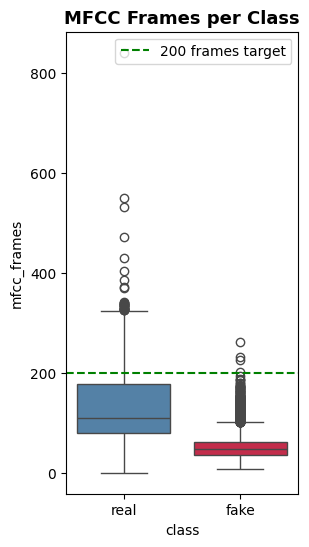

In [ ]:
fig, ax = plt.subplots(figsize=(3, 6))
sns.boxplot(data=eda_df, x="class", y="mfcc_frames", palette={"real": "steelblue", "fake": "crimson"}, ax=ax)
ax.axhline(y=200, color="green", linestyle="--", label="200 frames target")
ax.set_title("MFCC Frames per Class", fontsize=13, fontweight="bold")
ax.legend()
plt.show()


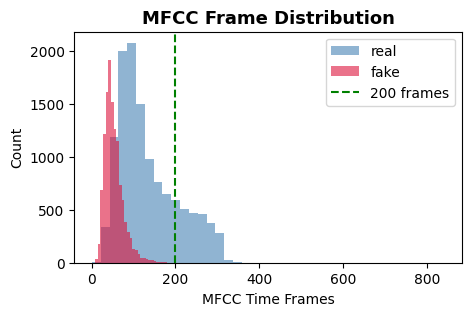

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
for i, cls in enumerate(CLASSES):
    subset = eda_df[eda_df["class"] == cls]
    ax.hist(subset["mfcc_frames"], bins=40, alpha=0.6,
            label=cls, color=["steelblue", "crimson"][i])

ax.axvline(x=200, color="green", linestyle="--", label="200 frames")
ax.set_title("MFCC Frame Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("MFCC Time Frames")
ax.set_ylabel("Count")
ax.legend()
plt.show()

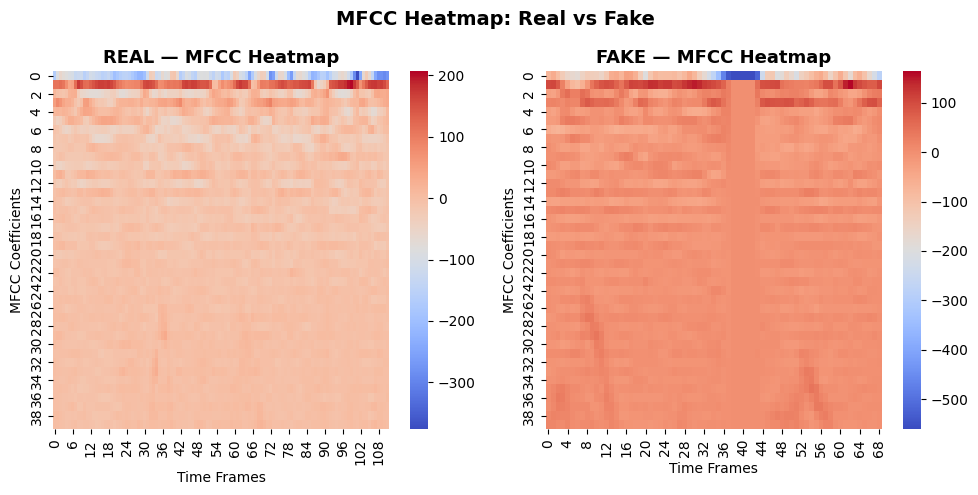

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, cls in enumerate(CLASSES):
    fpath = os.path.join(TRAIN_DIR, cls, os.listdir(os.path.join(TRAIN_DIR, cls))[0])
    audio, sr = librosa.load(fpath, sr=16000)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    sns.heatmap(mfcc, ax=axes[i], cmap="coolwarm", cbar=True)
    axes[i].set_title(f"{cls.upper()} — MFCC Heatmap", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Time Frames")
    axes[i].set_ylabel("MFCC Coefficients")

plt.suptitle("MFCC Heatmap: Real vs Fake", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Preprocessing Pipeline

Raw audio files vary in duration, sample rate, volume, and noise levels.
We standardize every file through the same pipeline before feature extraction
so the model receives clean, consistent inputs.

## Preprocessing Constants

Before writing any preprocessing code, we define all key parameters upfront.
Every value here is a deliberate choice backed by either our EDA results or
established speech processing research and not arbitrary defaults.

**TARGET_SR = 16000 Hz**
EDA confirmed all files are already at 16kHz. This is also the research
standard for speech tasks that captures all frequencies relevant to human voice.

**DURATION = 5 seconds**
EDA showed most files fall under 5 seconds. We fix all audio to this length
shorter files get zero-padded, longer ones get trimmed from the end.

**HOP_LENGTH = 512**
Librosa default. The MFCC window slides every 512 samples across the audio.
Smaller hop = more frames = heavier computation. 512 is the sweet spot.

**N_FFT = 2048**
Librosa default FFT window size. Larger window gives better frequency
resolution — 2048 works well for speech signals.

**MAX_FRAMES = 156**
Derived directly from our constants: 80,000 samples / 512 hop = 156 frames.
This is mathematically consistent with our chosen duration — not a guess.

**N_MFCC = 40**
Research standard for deepfake audio detection. Low coefficients capture
broad vocal patterns, high coefficients capture subtle AI artifacts.
13 is too few, 128 adds noise so 40 is the sweet spot.

**INPUT_SHAPE = (40 × 156 × 1)**
Final shape of every sample fed into the CNN.
Treated like a grayscale image — 40 rows, 156 columns, 1 channel.

In [4]:
TARGET_SR   = 16000
DURATION    = 5
MAX_LEN     = TARGET_SR * DURATION    # 80,000 samples
HOP_LENGTH  = 512
N_FFT       = 2048
MAX_FRAMES  = MAX_LEN // HOP_LENGTH   # 156 frames
N_MFCC      = 40
INPUT_SHAPE = (N_MFCC, MAX_FRAMES, 1)

print("Constants defined")
print(f"  Target SR   : {TARGET_SR} Hz")
print(f"  Duration    : {DURATION} sec")
print(f"  Max samples : {MAX_LEN}")
print(f"  Max frames  : {MAX_FRAMES}")
print(f"  CNN input   : {INPUT_SHAPE}")

Constants defined
  Target SR   : 16000 Hz
  Duration    : 5 sec
  Max samples : 80000
  Max frames  : 156
  CNN input   : (40, 156, 1)


In [ ]:
def load_and_validate(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=None)
        if len(audio) == 0:
            return None, None
        return audio, sr
    except:
        return None, None

In [ ]:
def preprocess_audio(audio, sr):
    # Resample to 16kHz
    if sr != TARGET_SR:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=TARGET_SR)

    # Convert to mono
    if audio.ndim > 1:
        audio = librosa.to_mono(audio)

    # Remove DC offset
    audio = audio - np.mean(audio)

    # Pre-emphasis filter
    audio = np.append(audio[0], audio[1:] - 0.97 * audio[:-1])

    # Normalize amplitude
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val

    # Trim silence
    audio, _ = librosa.effects.trim(audio, top_db=20)

    return audio

In [ ]:
def fix_duration(audio):
    if len(audio) < MAX_LEN:
        audio = np.pad(audio, (0, MAX_LEN - len(audio)))
    else:
        audio = audio[:MAX_LEN]
    return audio

In [ ]:
def augment_audio(audio):
    choice = np.random.randint(0, 3)

    if choice == 0:
        audio = librosa.effects.time_stretch(audio, rate=np.random.uniform(0.9, 1.1))
    elif choice == 1:
        audio = librosa.effects.pitch_shift(audio, sr=TARGET_SR, n_steps=np.random.randint(-2, 3))
    else:
        audio = audio + np.random.normal(0, 0.005, len(audio))

    return audio

Data augmentation was applied exclusively to training samples to improve model generalization. Random time stretching, pitch shifting, and additive Gaussian noise were used to simulate natural variations in speech while preserving class labels. This increases the diversity of training examples and reduces overfitting.

In [ ]:
def extract_mfcc(audio):
    # Extract 40 MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=TARGET_SR, n_mfcc=N_MFCC)

    # Standardize per coefficient
    mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / (np.std(mfcc, axis=1, keepdims=True) + 1e-6)

    # Fix shape to (40, 200)
    if mfcc.shape[1] < MAX_FRAMES:
        mfcc = np.pad(mfcc, ((0, 0), (0, MAX_FRAMES - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :MAX_FRAMES]

    # Add channel dimension → (40, 200, 1)
    return mfcc[..., np.newaxis]

In [ ]:
def pipeline(file_path, augment=False):
    # Load
    audio, sr = load_and_validate(file_path)
    if audio is None:
        return None

    # Preprocess
    audio = preprocess_audio(audio, sr)

    # Fix duration
    audio = fix_duration(audio)

    # Augment (train only)
    if augment:
        audio = augment_audio(audio)
        audio = fix_duration(audio)  # re-fix after augmentation

    # Extract MFCCs
    return extract_mfcc(audio)

print("Pipeline ready")

Pipeline ready


## Data Loading & Feature Extraction

We now run every audio file through our preprocessing pipeline.
The output is three ready-to-use numpy arrays for training, validation and testing.


In [ ]:
# Encode class labels as binary
# real = 0, fake = 1
LABEL_MAP = {"real": 0, "fake": 1}
print("Label mapping:", LABEL_MAP)

In [ ]:
from tqdm import tqdm

def load_dataset(split_dir, augment=False):
    X, y = [], []

    for label, cls in enumerate(CLASSES):
        cls_dir = os.path.join(split_dir, cls)
        files   = os.listdir(cls_dir)

        for fname in tqdm(files, desc=f"{cls}"):
            fpath  = os.path.join(cls_dir, fname)
            result = pipeline(fpath, augment=augment)

            if result is not None:
                X.append(result)
                y.append(LABEL_MAP[cls])

    return np.array(X), np.array(y)

In [29]:
print("Processing training data...")
X_train, y_train = load_dataset(TRAIN_DIR, augment=True)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

print("\nProcessing validation data...")
X_val, y_val = load_dataset(VAL_DIR, augment=False)
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")

print("\nProcessing test data...")
X_test, y_test = load_dataset(TEST_DIR, augment=False)
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Processing training data...


fake: 100%|██████████| 26927/26927 [15:53<00:00, 28.23it/s]


X_train: (53866, 40, 156, 1), y_train: (53866,)

Processing validation data...


fake: 100%|██████████| 5398/5398 [01:01<00:00, 87.65it/s] 


X_val: (10798, 40, 156, 1), y_val: (10798,)

Processing test data...


fake: 100%|██████████| 2370/2370 [00:26<00:00, 88.68it/s] 


X_test: (4634, 40, 156, 1), y_test: (4634,)


In [30]:
# Save to disk so we never have to reprocess again
# If Colab resets, just load these instead of rerunning the pipeline

np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_val.npy",   X_val)
np.save("y_val.npy",   y_val)
np.save("X_test.npy",  X_test)
np.save("y_test.npy",  y_test)

print("Arrays saved successfully")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")

Arrays saved successfully
  X_train : (53866, 40, 156, 1)
  X_val   : (10798, 40, 156, 1)
  X_test  : (4634, 40, 156, 1)


In [ ]:
# Skip this cell if arrays are already in memory
# Only run if Colab session restarted

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val   = np.load("X_val.npy")
y_val   = np.load("y_val.npy")
X_test  = np.load("X_test.npy")
y_test  = np.load("y_test.npy")

print("Arrays loaded successfully")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")

##Model 1 - CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, BatchNormalization, MaxPooling2D,
                                     Flatten, Dense, Dropout)

def build_cnn(input_shape):
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.3),

        # Classifier
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')  # binary output
    ])
    return model

cnn_model = build_cnn(INPUT_SHAPE)
cnn_model.summary()

In [ ]:
from keras.optimizers import Adam

cnn_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

print("Model compiled successfully")

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    # Stop training if val_loss doesn't improve for 5 epochs
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),

    # Save best model automatically
    ModelCheckpoint('best_cnn_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),

    # Reduce learning rate if val_loss plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Callbacks ready")

In [ ]:
history = cnn_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 8,
    batch_size      = 32,
    callbacks       = callbacks
)

print("Training complete!")

In [ ]:
# Save the model as it is right now
cnn_model.save("cnn_model_final.keras")
print("Model saved!")

In [ ]:
cnn_model.save("/content/drive/MyDrive/deepfake_audio/cnn_model_final.keras")
print("Saved to Drive!")

In [ ]:
from google.colab import files

# Download best model to your PC
files.download("best_cnn_model.keras")
files.download("cnn_model_final.keras")

In [ ]:
# Test on 1000 samples first to make sure training works
history = cnn_model.fit(
    X_train[:1000], y_train[:1000],
    validation_data = (X_val[:200], y_val[:200]),
    epochs          = 3,
    batch_size      = 32,
    callbacks       = callbacks
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='crimson')
axes[0].set_title("Accuracy over Epochs", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='crimson')
axes[1].set_title("Loss over Epochs", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("CNN Training History", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from keras.models import load_model

# Load best model
cnn_model = load_model("best_cnn_model.keras")
print("Model loaded!")

# Load arrays
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")
print("Arrays loaded!")

# Evaluate on test set
loss, accuracy = cnn_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

## Model Evaluation CNN

We evaluate the CNN model on the test set using all required metrics:
Accuracy, F1 Score, Confusion Matrix, Per-Class Accuracy, and EER.

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report)

# Get predictions
y_pred_prob = cnn_model.predict(X_test, verbose=1)  # probabilities
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()  # binary predictions
y_true      = y_test.astype(int)

print("Predictions done!")

In [ ]:
accuracy  = accuracy_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

print("=" * 40)
print("       CNN EVALUATION METRICS")
print("=" * 40)

metrics = [
    ("Test Accuracy",  f"{accuracy*100:.2f}%"),
    ("F1 Score",       f"{f1*100:.2f}%"),
]

for i, (label, value) in enumerate(metrics):
    print(f"  {i+1}. {label:<20}: {value}")

In [ ]:
cm        = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

real_accuracy = tn / (tn + fp)  # real correctly classified
fake_accuracy = tp / (tp + fn)  # fake correctly classified

print("Per-Class Accuracy:")
print(f"  Real (Genuine) : {real_accuracy*100:.2f}%  (target ≥ 75%)")
print(f"  Fake (Deepfake): {fake_accuracy*100:.2f}%  (target ≥ 75%)")

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"], ax=ax)

ax.set_title("Confusion Matrix — CNN", fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
fnr = 1 - tpr

# EER is where FPR and FNR are closest
eer_index = np.argmin(np.abs(fpr - fnr))
eer        = (fpr[eer_index] + fnr[eer_index]) / 2

print(f"  EER : {eer*100:.2f}%  (target ≤ 12%)")

In [ ]:
print("=" * 40)
print("     FINAL CNN EVALUATION REPORT")
print("=" * 40)

results = [
    ("Test Accuracy",    f"{accuracy*100:.2f}%",        "≥ 80%",  "✅" if accuracy >= 0.8  else "❌"),
    ("F1 Score",         f"{f1*100:.2f}%",              "≥ 80%",  "✅" if f1 >= 0.8        else "❌"),
    ("EER",              f"{eer*100:.2f}%",             "≤ 12%",  "✅" if eer <= 0.12      else "❌"),
    ("Real Accuracy",    f"{real_accuracy*100:.2f}%",   "≥ 75%",  "✅" if real_accuracy >= 0.75 else "❌"),
    ("Fake Accuracy",    f"{fake_accuracy*100:.2f}%",   "≥ 75%",  "✅" if fake_accuracy >= 0.75 else "❌"),
]

for label, value, target, status in results:
    print(f"  {status} {label:<20}: {value:<10} (target {target})")

## Model 2 — LSTM (Long Short-Term Memory)

While CNN treats the MFCC as a 2D image, LSTM treats it as a time sequence.
Each of the 156 time frames is fed as a step into the LSTM allowing the model
to capture temporal patterns and dependencies in speech that CNN might miss.
Input shape: (156 time frames × 40 MFCC coefficients)

In [1]:
import gc

# Delete CNN arrays we don't need anymore
del X_train, X_val, X_test

# Force garbage collection
gc.collect()

print("Memory freed!")

NameError: name 'X_train' is not defined

In [5]:
# Reload and reshape directly for LSTM
import numpy as np
X_train_lstm = np.load("/content/X_train.npy").reshape(-1, MAX_FRAMES, N_MFCC)
X_val_lstm   = np.load("/content/X_val.npy").reshape(-1, MAX_FRAMES, N_MFCC)
X_test_lstm  = np.load("/content/X_test.npy").reshape(-1, MAX_FRAMES, N_MFCC)

print(f"X_train_lstm : {X_train_lstm.shape}")
print(f"X_val_lstm   : {X_val_lstm.shape}")
print(f"X_test_lstm  : {X_test_lstm.shape}")

X_train_lstm : (53866, 156, 40)
X_val_lstm   : (10798, 156, 40)
X_test_lstm  : (4634, 156, 40)


In [6]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization

def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),

        LSTM(64, return_sequences=False),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(1, activation='sigmoid')
    ])
    return model

lstm_model = build_lstm((MAX_FRAMES, N_MFCC))
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 156, 128)       │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 156, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,417 (548.50 KB)

 Trainable params: 140,289 (548.00 KB)

 Non-trainable params: 128 (512.00 B)

In [7]:
from keras.optimizers import Adam

lstm_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

print("LSTM model compiled!")

LSTM model compiled!


In [8]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_lstm_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]
print("Callbacks ready!")

Callbacks ready!


In [9]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
y_train = np.load("/content/y_train.npy")
y_val   = np.load("/content/y_val.npy")
y_test  = np.load("/content/y_test.npy")

print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")

y_train : (53866,)
y_val   : (10798,)
y_test  : (4634,)


In [12]:
lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data = (X_val_lstm, y_val),
    epochs          = 10,
    batch_size      = 32,
    callbacks       = lstm_callbacks
)
print("LSTM Training complete!")

Epoch 1/10
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6805 - loss: 0.6119
Epoch 1: val_accuracy improved from None to 0.85312, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.7666 - loss: 0.4946 - val_accuracy: 0.8531 - val_loss: 0.3597 - learning_rate: 0.0010
Epoch 2/10
1681/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8413 - loss: 0.3806
Epoch 2: val_accuracy improved from 0.85312 to 0.86155, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.8438 - loss: 0.3774 - val_accuracy: 0.8615 - val_loss: 0.3566 - learning_rate: 0.0010
Epoch 3/10
1681/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8589 - loss: 0.3524
Epoch 3: val_accuracy improved from 0.86155 to 0.87025, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model

In [14]:
lstm_history_2 = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data = (X_val_lstm, y_val),
    epochs          = 15,   # total epochs = 15 (runs 5 more from epoch 10)
    batch_size      = 32,
    callbacks       = lstm_callbacks,
    initial_epoch   = 10    # start from epoch 10
)

Epoch 11/15
1681/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9592 - loss: 0.1192
Epoch 11: val_accuracy did not improve from 0.94814
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9599 - loss: 0.1165 - val_accuracy: 0.9438 - val_loss: 0.1802 - learning_rate: 0.0010
Epoch 12/15
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9631 - loss: 0.1023
Epoch 12: val_accuracy did not improve from 0.94814
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9621 - loss: 0.1053 - val_accuracy: 0.9457 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 13/15
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9679 - loss: 0.0954
Epoch 13: val_accuracy did not improve from 0.94814

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9674 - loss: 0.0956 - val_accuracy: 0.9232 - val_loss: 0.2277 - learning_rate: 0.0010
Epoch 14/15
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc

##Evaluation Metrices

In [15]:
from google.colab import files
files.download("best_lstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from keras.models import load_model

# Load best LSTM model
lstm_model = load_model("best_lstm_model.keras")
print("LSTM model loaded!")

# Reshape X_test for LSTM
X_test_lstm = np.load("/content/X_test.npy").reshape(-1, MAX_FRAMES, N_MFCC)
print(f"X_test_lstm shape: {X_test_lstm.shape}")

# Basic evaluation
loss, accuracy = lstm_model.evaluate(X_test_lstm, y_test, verbose=1)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

LSTM model loaded!
X_test_lstm shape: (4634, 156, 40)
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8886 - loss: 0.3051
Test Accuracy : 88.86%
Test Loss     : 0.3051


In [17]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve

# Predictions
y_pred_prob_lstm = lstm_model.predict(X_test_lstm, verbose=1)
y_pred_lstm      = (y_pred_prob_lstm > 0.5).astype(int).flatten()
y_true           = y_test.astype(int)

# Metrics
accuracy  = accuracy_score(y_true, y_pred_lstm)
f1        = f1_score(y_true, y_pred_lstm)
cm        = confusion_matrix(y_true, y_pred_lstm)
tn, fp, fn, tp = cm.ravel()

real_accuracy = tn / (tn + fp)
fake_accuracy = tp / (tp + fn)

fpr, tpr, _ = roc_curve(y_true, y_pred_prob_lstm)
fnr         = 1 - tpr
eer_index   = np.argmin(np.abs(fpr - fnr))
eer         = (fpr[eer_index] + fnr[eer_index]) / 2

print("Predictions done!")

145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Predictions done!


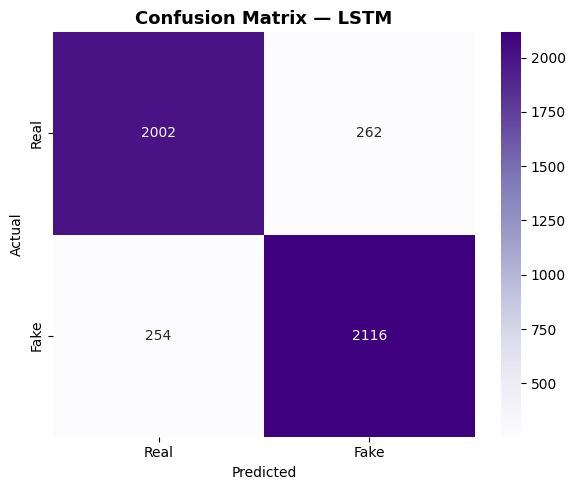

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"], ax=ax)
ax.set_title("Confusion Matrix — LSTM", fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [21]:
print("=" * 40)
print("     FINAL LSTM EVALUATION REPORT")
print("=" * 40)

results = [
    ("Test Accuracy",  f"{accuracy*100:.2f}%",      "≥ 80%", "✅" if accuracy >= 0.8       else "❌"),
    ("F1 Score",       f"{f1*100:.2f}%",            "≥ 80%", "✅" if f1 >= 0.8             else "❌"),
    ("EER",            f"{eer*100:.2f}%",           "≤ 12%", "✅" if eer <= 0.12           else "❌"),
    ("Real Accuracy",  f"{real_accuracy*100:.2f}%", "≥ 75%", "✅" if real_accuracy >= 0.75 else "❌"),
    ("Fake Accuracy",  f"{fake_accuracy*100:.2f}%", "≥ 75%", "✅" if fake_accuracy >= 0.75 else "❌"),
]

for label, value, target, status in results:
    print(f"  {status} {label:<20}: {value:<10} (target {target})")

     FINAL LSTM EVALUATION REPORT
  ✅ Test Accuracy       : 88.86%     (target ≥ 80%)
  ✅ F1 Score            : 89.13%     (target ≥ 80%)
  ✅ EER                 : 11.16%     (target ≤ 12%)
  ✅ Real Accuracy       : 88.43%     (target ≥ 75%)
  ✅ Fake Accuracy       : 89.28%     (target ≥ 75%)


In [22]:
print("=" * 50)
print("      CNN vs LSTM — FINAL COMPARISON")
print("=" * 50)

comparison = [
    ("Test Accuracy", "92.73%", "88.86%"),
    ("F1 Score",      "93.30%", "89.13%"),
    ("EER",          "4.38%",  "11.16%"),
    ("Real Accuracy", "86.17%", "88.43%"),
    ("Fake Accuracy", "98.99%", "89.28%"),
]

print(f"  {'Metric':<20} {'CNN':>10} {'LSTM':>10}")
print("-" * 45)
for i, (metric, cnn, lstm) in enumerate(comparison):
    print(f"  {metric:<20} {cnn:>10} {lstm:>10}")

print("-" * 45)
print("\n  ✅ Selected Model: CNN")
print("  Reason: Higher accuracy, F1, and significantly")
print("  better EER (4.38% vs 11.16%)")

      CNN vs LSTM — FINAL COMPARISON
  Metric                      CNN       LSTM
---------------------------------------------
  Test Accuracy            92.73%     88.86%
  F1 Score                 93.30%     89.13%
  EER                       4.38%     11.16%
  Real Accuracy            86.17%     88.43%
  Fake Accuracy            98.99%     89.28%
---------------------------------------------

  ✅ Selected Model: CNN
  Reason: Higher accuracy, F1, and significantly
  better EER (4.38% vs 11.16%)
